# HOMEWORK - Buổi 7: Classification
**Họ và tên:** Phan Gia Huy

## Bài 1: Titanic Dataset
Sử dụng Logistic Regression để dự đoán hành khách sống sót.

--- KẾT QUẢ ĐÁNH GIÁ LOGISTIC REGRESSION (TITANIC) ---
Accuracy:  0.8045
Precision: 0.7931
Recall:    0.6667
F1-score:  0.7244


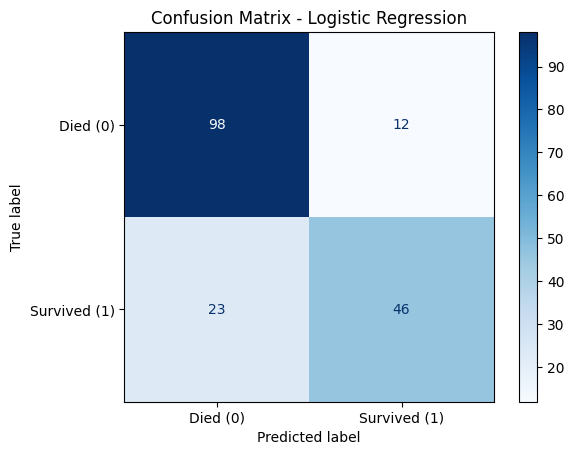

In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Tải và làm sạch dữ liệu Titanic
df_titanic = sns.load_dataset("titanic")
leaky_cols = ['alive', 'who', 'adult_male', 'class', 'deck', 'embark_town', 'alone']
df_titanic = df_titanic.drop(columns=leaky_cols)

X_tit = df_titanic.drop(columns=['survived'])
y_tit = df_titanic['survived']

# Chia tập có stratify
X_train_tit, X_test_tit, y_train_tit, y_test_tit = train_test_split(X_tit, y_tit, test_size=0.2, stratify=y_tit, random_state=42)

# Xây dựng Pipeline
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

preprocess = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy='median')), ("scaler", RobustScaler())]), num_cols),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy='most_frequent')), ("onehot", OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols),
    ("ord", "passthrough", ord_cols)
])

# Huấn luyện Logistic Regression
log_reg = Pipeline([
    ('preprocessor', preprocess),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])
log_reg.fit(X_train_tit, y_train_tit)
y_pred_log = log_reg.predict(X_test_tit)

# Đánh giá
print("--- KẾT QUẢ ĐÁNH GIÁ LOGISTIC REGRESSION (TITANIC) ---")
print(f"Accuracy:  {accuracy_score(y_test_tit, y_pred_log):.4f}")
print(f"Precision: {precision_score(y_test_tit, y_pred_log):.4f}")
print(f"Recall:    {recall_score(y_test_tit, y_pred_log):.4f}")
print(f"F1-score:  {f1_score(y_test_tit, y_pred_log):.4f}")

cm = confusion_matrix(y_test_tit, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Died (0)", "Survived (1)"])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

**Nhận xét so sánh Logistic Regression vs Linear Regression:**
Đối với bài toán phân loại hành khách sống sót (phân loại nhị phân), **Logistic Regression** hoàn toàn vượt trội so với Linear Regression vì:
1. **Bản chất ngõ ra:** Linear Regression dự đoán ra một số thực liên tục, rất khó để thiết lập ngưỡng quyết định rõ ràng. Logistic Regression sử dụng hàm Sigmoid đưa ngõ ra về khoảng [0, 1], biểu diễn chính xác xác suất sống sót.
2. **Kháng nhiễu:** Logistic Regression phân tách không gian bằng Decision Boundary nên bền vững hơn với các điểm dữ liệu dị biệt (outliers) so với đường thẳng của Linear Regression.
3. **Hàm mất mát:** Thuật toán Logistic sử dụng Binary Cross-Entropy sinh ra mặt loss lồi, tối ưu hóa tốt hơn cho bài toán Classification.

## Bài 2: Dry Bean Dataset
Phân loại các loại hạt bằng Logistic Regression và K-Nearest Neighbors (KNN).

In [31]:
# Đọc dữ liệu Dry Bean
train_df = pd.read_excel("Dry_Bean_Dataset/Dry_Bean_Dataset.xlsx")
test_df = pd.read_excel("Dry_Bean_Dataset/Dry_Bean_Dataset.xlsx")

X_train_bean = train_df.drop(columns=['Class'])
y_train_bean = train_df['Class']
X_test_bean = test_df.drop(columns=['Class'])
y_test_bean = test_df['Class']

# Encode nhãn chữ sang số và Scale dữ liệu (Bắt buộc cho KNN)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_bean)
y_test_enc = le.transform(y_test_bean)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bean)
X_test_scaled = scaler.transform(X_test_bean)

# Logistic Regression (Multiclass)
lr_bean = LogisticRegression(max_iter=2000, random_state=42)
lr_bean.fit(X_train_scaled, y_train_enc)
y_pred_lr_bean = lr_bean.predict(X_test_scaled)

print("--- LOGISTIC REGRESSION (DRY BEAN) ---")
print(f"Accuracy: {accuracy_score(y_test_enc, y_pred_lr_bean):.4f}\n")

# K-Nearest Neighbors (KNN)
knn_bean = KNeighborsClassifier(n_neighbors=5)
knn_bean.fit(X_train_scaled, y_train_enc)
y_pred_knn_bean = knn_bean.predict(X_test_scaled)

print("--- K-NEAREST NEIGHBORS (DRY BEAN) ---")
print(f"Accuracy: {accuracy_score(y_test_enc, y_pred_knn_bean):.4f}\n")

--- LOGISTIC REGRESSION (DRY BEAN) ---
Accuracy: 0.9250

--- K-NEAREST NEIGHBORS (DRY BEAN) ---
Accuracy: 0.9426

